# Imports

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io
from sklearn.model_selection import train_test_split
import pandas as pd
import random
from collections import defaultdict
import pickle

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D

In [7]:
random.seed(42)

# Auxiliar functions
## Dataset

In [8]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [9]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007']


In [10]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path)

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [11]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007


## Plotting function

In [12]:
def plot_from_history(history, epochs):

    # Manejar tanto objeto history como dict directamente
    if hasattr(history, 'history'):
        hist = history.history
    else:
        hist = history

    acc = hist['accuracy']
    val_acc = hist['val_accuracy']

    loss = hist['loss']
    val_loss = hist['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

## Save and load history

In [13]:
def save_history(history):
    with open("history.pkl", "wb") as f:
        pickle.dump(history.history, f)

def load_history():    
    if os.path.exists("history.pkl"):
        with open("history.pkl", "rb") as f:
            loaded_history = pickle.load(f)
        print("Historial cargado.")
        return loaded_history
    else:
        print("No se encontró historial guardado.")
        return None

# Time Series
Given a window of n images, predict n+1

In [14]:
seq_by_session = {}

for entry in os.listdir(path_capturasVR):
    entry_path = os.path.join(path_capturasVR, entry)
    # comprobar que es un directorio y que empieza por "Session_"
    if os.path.isdir(entry_path) and entry.startswith("Session_"):
        # filtrar imágenes .png y ordenar
        image_files = [f for f in os.listdir(entry_path) if f.endswith(".png")]
        image_paths = [os.path.join(entry_path, f) for f in sorted(image_files)]
        seq_by_session[entry] = image_paths

In [15]:
# Crear X_train e Y_train y X_test e Y_test
sessions = list(seq_by_session.keys())

train_ratio = 0.8
n_train = int(len(sessions) * train_ratio)

random.shuffle(sessions)
sessions_train = sessions[:n_train]
sessions_test = sessions[n_train:]

In [16]:
print(sessions_train)
print(sessions_test)

['Session_002', 'Session_004', 'Session_005', 'Session_003', 'Session_007']
['Session_001', 'Session_006']


In [17]:
seq_train = {k: seq_by_session[k] for k in sessions_train}
seq_test  = {k: seq_by_session[k] for k in sessions_test}

In [18]:
def load_and_preprocess(img_path):
    img = image.load_img(img_path, target_size=(256, 256))  
    img = image.img_to_array(img)  # (256, 256, 3)
    img = img / 255.0  
    return img

In [19]:
def sequence_imgs(session_path, n_timesteps): 
    X, Y = [], []

    if len(session_path) <= n_timesteps:
        return X, Y

    for i in range(len(session_path) - n_timesteps):
        input_paths = session_path[i:i+n_timesteps]         # 5 imágenes
        target_path = session_path[i+n_timesteps]           # 1 imagen siguiente

        x_batch = [load_and_preprocess(p) for p in input_paths]
        y_img   = load_and_preprocess(target_path)

        X.append(np.array(x_batch))
        Y.append(y_img)

    return np.array(X), np.array(Y)

In [20]:
window_size = 5

def sequence_imgs_all_sessions(seq_dict, n_timesteps):
    X_total, Y_total = [], []
    for session, paths in seq_dict.items():
        X_sess, Y_sess = sequence_imgs(paths, n_timesteps)
        X_total.extend(X_sess)
        Y_total.extend(Y_sess)
        
    return np.array(X_total), np.array(Y_total)

In [21]:
X_train, Y_train = sequence_imgs_all_sessions(seq_train, window_size)
X_test,  Y_test  = sequence_imgs_all_sessions(seq_test,  window_size)

In [22]:
model_ts = Sequential([
   
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True,
        input_shape=(5, 256, 256, 3)
    ),
    BatchNormalization(),
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),
    Conv2D(
        filters=3,
        kernel_size=(3, 3),
        activation="sigmoid",
        padding="same"
    )
])

c:\Users\aitor\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model_ts.compile(optimizer="adam", loss="mse", metrics=["mae", "accuracy"])
model_ts.summary()

epochs_ts = 10
# Training
history = model_ts.fit(
    X_train, Y_train,
    epochs=epochs_ts,
    batch_size=4,
    verbose=1, 
    validation_split=0.2
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 256, 256,    │        40,448 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 256, 256,    │           128 │
│ (BatchNormalization)            │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 256, 256, 32)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,299 (450.39 KB)

 Trainable params: 115,235 (450.14 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.9520 - loss: 0.0082 - mae: 0.0467 - val_accuracy: 0.9702 - val_loss: 0.0415 - val_mae: 0.1653
Epoch 2/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.9605 - loss: 0.0065 - mae: 0.0364 - val_accuracy: 0.9753 - val_loss: 0.0086 - val_mae: 0.0553
Epoch 3/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 337s 1s/step - accuracy: 0.9631 - loss: 0.0063 - mae: 0.0341 - val_accuracy: 0.8264 - val_loss: 0.0073 - val_mae: 0.0464
Epoch 4/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 335s 1s/step - accuracy: 0.9624 - loss: 0.0063 - mae: 0.0339 - val_accuracy: 0.9666 - val_loss: 0.0078 - val_mae: 0.0492
Epoch 5/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.9667 - loss: 0.0062 - mae: 0.0326 - val_accuracy: 0.9705 - val_loss: 0.0070 - val_mae: 0.0401
Epoch 6/10
292/292 ━━━━━━━━━━━━━━━━━━━━ 334s 1s/step - accuracy: 0.9681 - loss: 0.0061 - mae: 0.0321 - val_accuracy: 0.9706 - val_loss: 0.0067 - val_mae: 0.0350
Epoch 7/10
292/292 ━━━━━━━━━━━━━━━

In [24]:
model_ts.save("modelo_prediccion_imagenes.keras")

In [25]:
model_ts = load_model("modelo_prediccion_imagenes.keras")

In [26]:
save_history(history)

In [27]:
history = load_history()

Historial cargado.


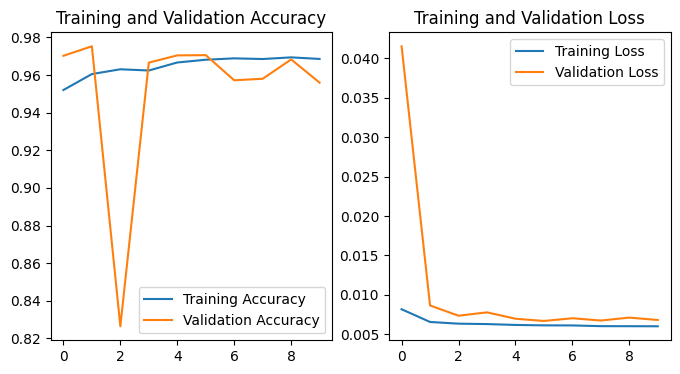

In [28]:
plot_from_history(history, epochs = epochs_ts)

In [29]:
def predict_next_image(model, session, inicio, fin, n_timesteps):

    paths = session[inicio:fin+1]         # imagenes de indice inicio a fin
    if len(paths) < n_timesteps:
        print("Warning: la ventana es menor que n_timesteps")
        return None

    # Asegurar que la ventana tiene exactamente n_timesteps
    last_n = paths[-n_timesteps:]
    last_n_imgs = [load_and_preprocess(p) for p in last_n]
    X = np.array([np.array(last_n_imgs)])  # (1, n_timesteps, 256, 256, 3)

    pred = model.predict(X)                # (1, 256, 256, 3)
    return pred[0]

In [30]:
ind = 0
test_session_name = sessions_test[ind]                   

test_session_paths = seq_by_session[test_session_name]      
ini = 0
fin = 100

y_pred = predict_next_image(model_ts, test_session_paths, ini, fin, window_size)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


Forma de y_pred: (256, 256, 3)


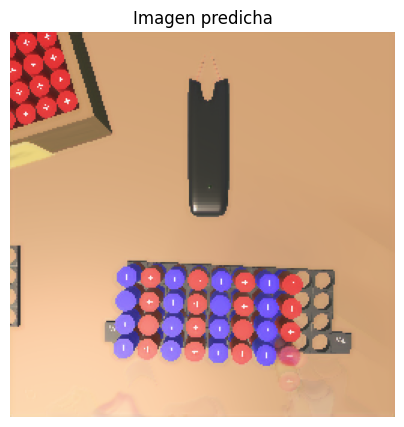

In [31]:
print("Forma de y_pred:", y_pred.shape)  # comprueba que es (256, 256, 3)

plt.figure(figsize=(5, 5))
plt.imshow(y_pred)
plt.title("Imagen predicha")
plt.axis("off")
plt.show()

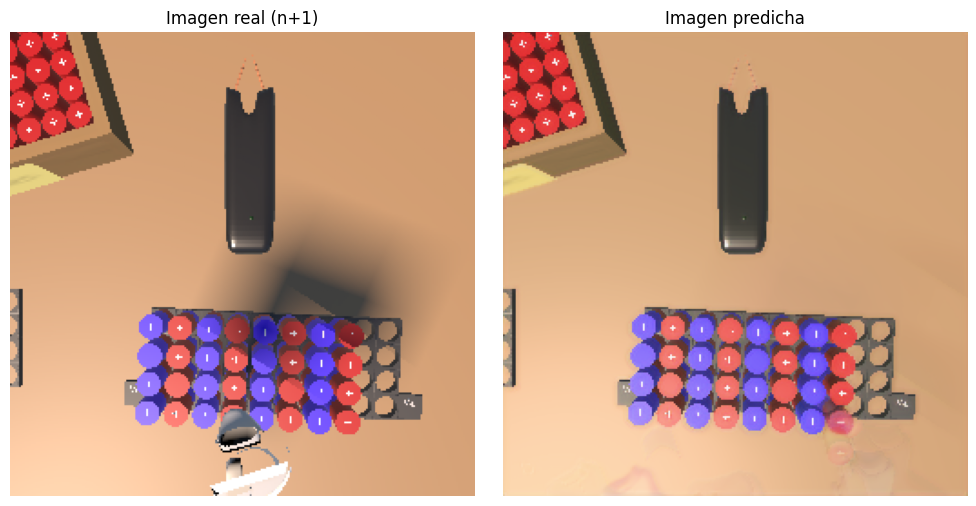

In [32]:
# Imagen real (la que el modelo debería predecir)
img_real = load_and_preprocess(test_session_paths[fin + 1])  # (256, 256, 3)

# Imagen predicha
img_pred = y_pred   # (256, 256, 3)

# Mostrar original y predicción lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img_real)
ax1.set_title("Imagen real (n+1)")
ax1.axis("off")

ax2.imshow(img_pred)
ax2.set_title("Imagen predicha")
ax2.axis("off")

plt.tight_layout()
plt.show()

Total de imágenes en la secuencia: 102
Última imagen (n+1) ruta: ../capturas/capturas_256x256/capturasVR\Session_001\capture_0101.png


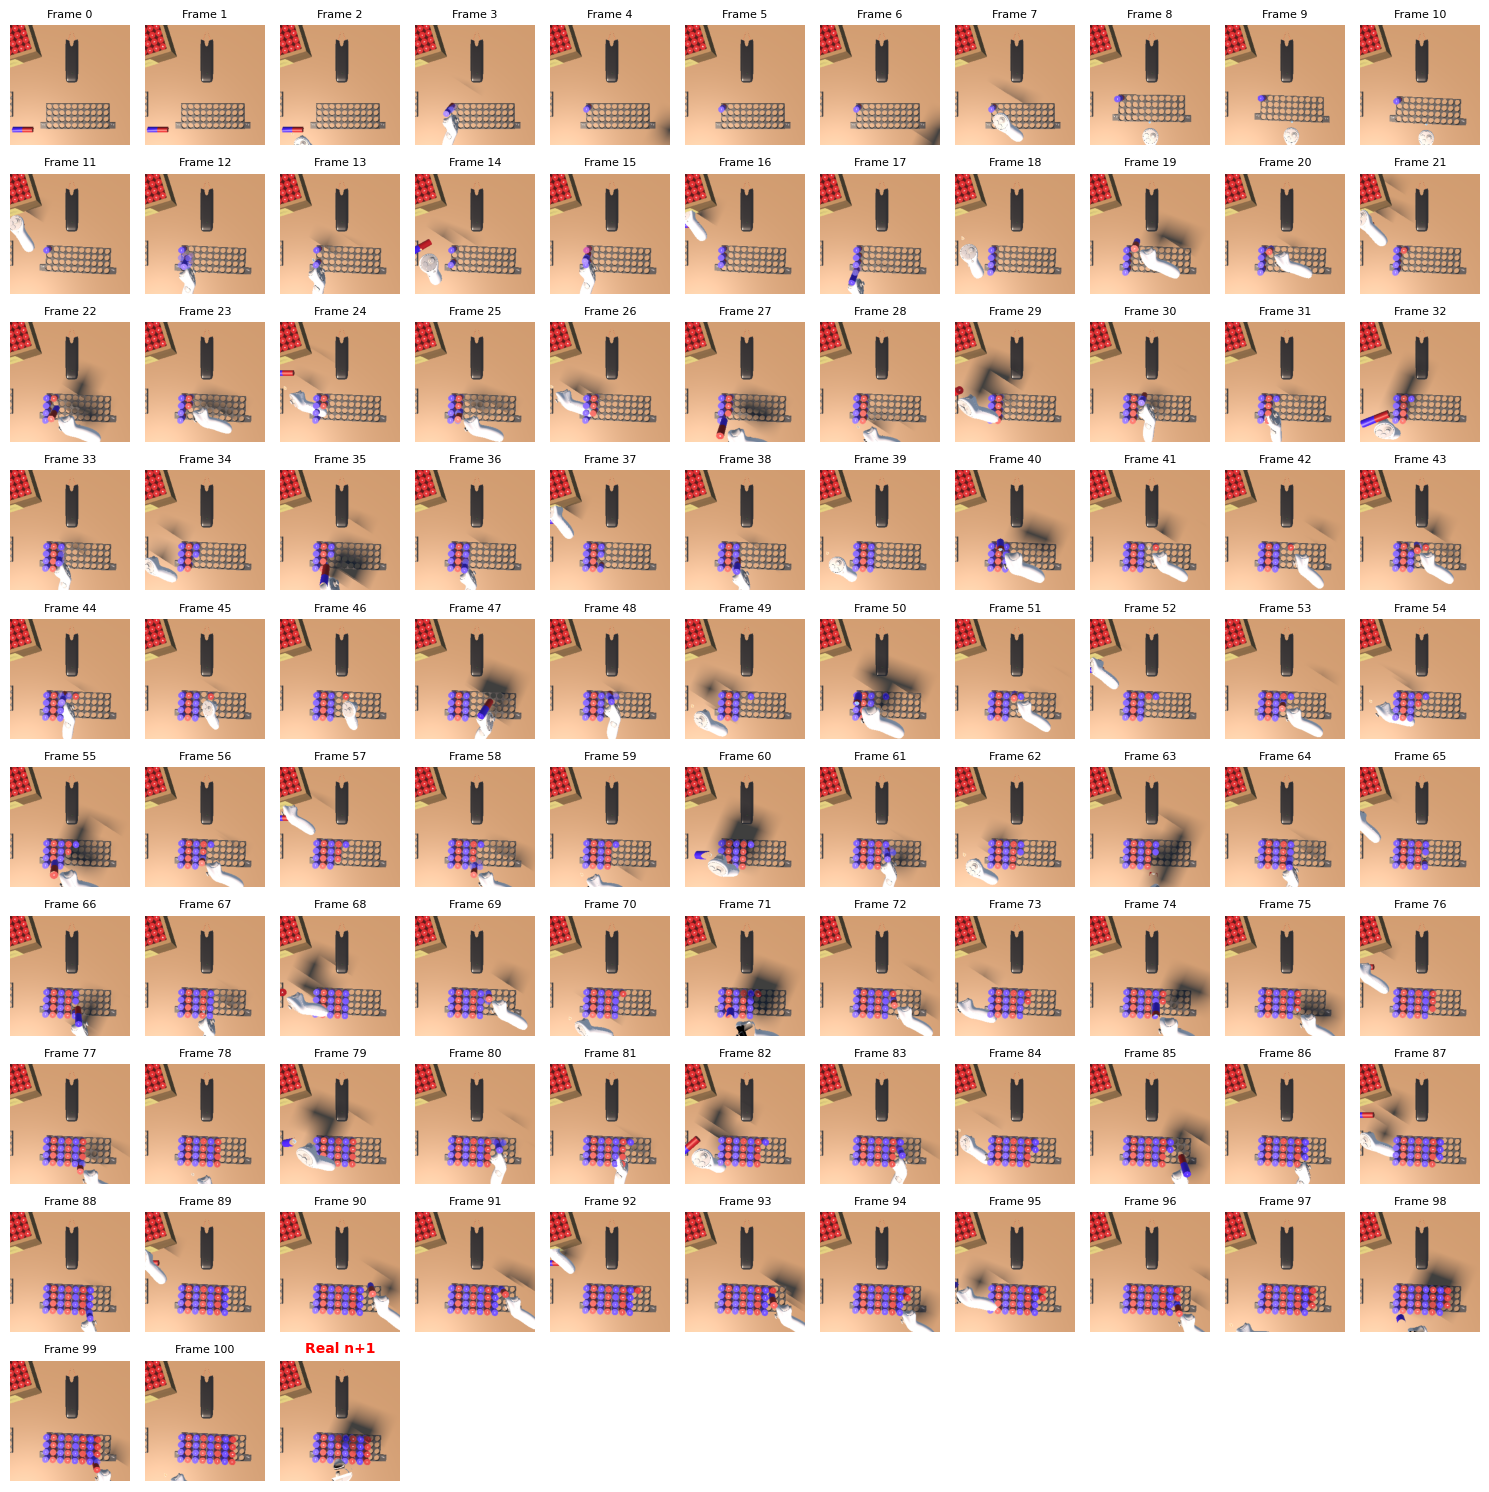

In [33]:
# Mostrar secuencia completa desde ini hasta fin + 1
sequence_paths = test_session_paths[ini:fin+2]  # ini a fin+1 inclusive

print(f"Total de imágenes en la secuencia: {len(sequence_paths)}")
print(f"Última imagen (n+1) ruta: {sequence_paths[-1] if len(sequence_paths) > 0 else 'No hay'}")

fig, axes = plt.subplots(10, 11, figsize=(15, 15))

# Aplanar los axes para iterar fácilmente
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    if idx < len(sequence_paths):
        img_path = sequence_paths[idx]
        img = load_and_preprocess(img_path)
        ax.imshow(img)
        
        is_last = (idx == len(sequence_paths) - 1)
        
        if is_last:
            ax.set_title("Real n+1", fontsize=10, color='red', weight='bold')
            # Agregar borde de color rojo a la imagen real
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
                spine.set_visible(True)
        else:
            ax.set_title(f"Frame {ini+idx}", fontsize=8)
    
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image Classification

In [34]:
# Filtrar filas válidas (si hay imágenes faltantes)
df_valid = df[df['full_path'].apply(os.path.exists)].copy()

# Cargar imágenes y etiquetas
images = []
labels = []

for _, row in df_valid.iterrows():
    img_path = row['full_path']
    label = row['label']
    
    # Cargar y preprocesar imagen
    img = load_and_preprocess(img_path)  # Usa la función existente
    images.append(img)
    labels.append(label)

# Convertir a arrays de NumPy
images = np.array(images)  # Forma: (num_samples, 256, 256, 3)
labels = np.array(labels)  # Forma: (num_samples,)

print(f"Total de imágenes cargadas: {len(images)}")
print(f"Forma de images: {images.shape}")
print(f"Forma de labels: {labels.shape}")

# Dividir en train y test (80% train, 20% test)
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train images: {train_images.shape}, Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}, Test labels: {test_labels.shape}")

Total de imágenes cargadas: 2108
Forma de images: (2108, 256, 256, 3)
Forma de labels: (2108,)
Train images: (1686, 256, 256, 3), Train labels: (1686,)
Test images: (422, 256, 256, 3), Test labels: (422,)


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_labels = le.fit_transform(train_labels)
test_labels = le.transform(test_labels)

In [41]:
data_augmentation = Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

def training_pipeline(model, epochs = 10, validation_split = 0.2, lr=0.001):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',   factor=0.5,  patience=7,verbose=1, min_lr=4e-10
    )
    model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])
    history = model.fit(train_images, train_labels,epochs=epochs,batch_size = 32,validation_split=validation_split,callbacks = [lr_callback])
    train_loss, train_acc = model.evaluate(train_images,  train_labels, verbose=2)
    test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
    return test_acc, train_acc, history

In [ ]:
model_class = Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    # Bloque 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Bloque 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Bloque 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # En lugar de Flatten(), usa GlobalAveragePooling2D()
    layers.GlobalAveragePooling2D(),                    
    layers.Dense(128, activation='relu'),               
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')                # 5 clases
])
epochs_class = 30
test_acc_class, train_acc_class, history_class = training_pipeline(model_class, epochs = epochs_class)
print(f"Test accuracy: {test_acc_class}\nTrain accuracy: {train_acc_class}")

Epoch 1/30


InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "C:\Users\aitor\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "C:\Users\aitor\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "C:\Users\aitor\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "C:\Users\aitor\AppData\Roaming\Python\Python312\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\aitor\AppData\Local\Python\pythoncore-3.12-64\Lib\asyncio\base_events.py", line 645, in run_forever

  File "c:\Users\aitor\AppData\Local\Python\pythoncore-3.12-64\Lib\asynci

In [ ]:
model_class.save("modelo_clasificacion_imagenes.keras")
save_history(history_class)

In [ ]:
plot_from_history(history_class, epochs = epochs_class)

In [ ]:
def encoder(prediction):
    # Para convertir predicción → etiqueta original
    pred_class = np.argmax(prediction)
    label_original = le.inverse_transform([pred_class])
    return label_original